# 02. Building "location" into numbers

*Rent Reality Check - London. Created by **Kevin Steepan**.*

---

## Where we are, and why this notebook exists

Notebook 01 found a clear pattern: central listings cost more. But the only
location information in the raw data is the **borough name** - and a borough is
huge. "Camden" covers a flat right on top of a Tube station *and* a house a
25-minute walk from one, and those two don't rent for the same price.

**This notebook's question:** if we work out a listing's *exact* situation - how
far to the nearest station, how lively the street is, how central it is - does that
help predict price, or has the borough label already told us everything useful?

The plan:
1. Pull stations, parks and food venues from a free map of the world (OpenStreetMap).
2. For each listing, turn its coordinates into six numbers describing its location.
3. Run a clean experiment: give a model the borough + basics, then the *same* model
   the borough + basics + the six new numbers, and see if it improves.

### The six features, and the everyday reason each might matter

| Feature | Plain meaning | Why a guest might pay for it |
|---|---|---|
| `dist_station_m` | metres to the nearest train/Tube/DLR station | you get around London by Tube; a short walk to one is a real plus |
| `stations_within_1km` | how many stations are within a km | more choice of where you can get to |
| `dist_center_m` | metres to Charing Cross (the official "centre of London") | rough proxy for "central and touristy" |
| `dist_restaurant_m`, `food_within_500m` | nearest, and count within 500 m, of restaurants / cafés / pubs / bars | a lively street is worth more on a short trip |
| `dist_park_m` | metres to the nearest green space (0 if you're in one) | some people want a park nearby |

I deliberately **left out schools and GP surgeries**. They'd matter for a year-long
tenancy; for a four-night stay they're irrelevant, and adding them would just be
noise. Matching the features to the actual use-case is part of the work.

## First, the one idea that trips everyone up: you can't measure distance on latitude/longitude

A latitude/longitude pair is an **angle** on a globe, in degrees. And a degree
means a *different real distance* depending on which direction you go. The cell
below shows exactly how different, near London.

> **Thought process.** I did not plan a section on coordinate systems. My first
> distance-to-station numbers were just wrong, in a way that took a while to spot
> because they looked plausible. Tracing it back to 'you cannot do flat geometry
> on angles' is exactly the kind of thing worth writing down so the next person
> (or the next me) does not lose an afternoon to it.

1° north ≈ 111.3 km   but   1° east ≈ 69.3 km


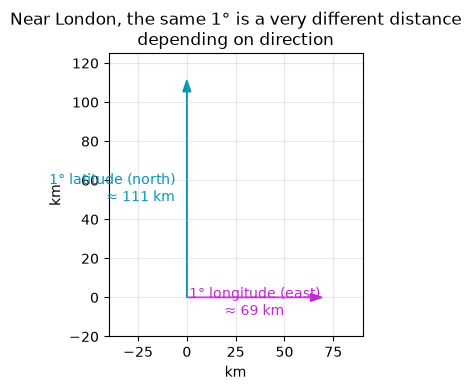

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# How far is 1 degree, on the ground, near London (latitude ~51.5°)?
lat0 = 51.5
km_per_deg_lat = 111.32  # roughly constant everywhere
km_per_deg_lon = 111.32 * np.cos(np.deg2rad(lat0))  # shrinks toward the poles

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.arrow(0, 0, km_per_deg_lon, 0, head_width=4, length_includes_head=True, color="#c026d3")
ax.arrow(0, 0, 0, km_per_deg_lat, head_width=4, length_includes_head=True, color="#0891b2")
ax.text(
    km_per_deg_lon / 2,
    -9,
    f"1° longitude (east)\n≈ {km_per_deg_lon:.0f} km",
    ha="center",
    color="#c026d3",
)
ax.text(
    -6,
    km_per_deg_lat / 2,
    f"1° latitude (north)\n≈ {km_per_deg_lat:.0f} km",
    va="center",
    ha="right",
    color="#0891b2",
)
ax.set_xlim(-40, 90)
ax.set_ylim(-20, 125)
ax.set_aspect("equal")
ax.set_title("Near London, the same 1° is a very different distance\ndepending on direction")
ax.set_xlabel("km")
ax.set_ylabel("km")
ax.grid(alpha=0.3)
plt.tight_layout()
print(f"1° north ≈ {km_per_deg_lat:.1f} km   but   1° east ≈ {km_per_deg_lon:.1f} km")

**What this means:** `sqrt(Δlat² + Δlon²)` on raw coordinates mixes kilometres and
"kilometres times 0.62" - the answer is meaningless. **If you're new: the fix is a
one-liner, `.to_crs(27700)`, before any distance maths.** The box explains it.

> ### Deeper: "projecting" to a metric coordinate system
>
> A **CRS** (coordinate reference system) is a recipe for turning positions on the
> curved Earth into coordinates. Two kinds matter here:
> - **Geographic** (`EPSG:4326`, plain GPS lat/long) - angles. Fine for *storing* a
>   position, useless for *measuring* between two.
> - **Projected** (`EPSG:27700`, the **British National Grid**) - the region is
>   flattened onto a plane and coordinates are in **metres**. Plain Pythagoras is
>   now accurate to a fraction of a percent over an area the size of London.
>
> (`EPSG` is just a registry of ID numbers for these systems.) So the pattern in
> `londonrent/geo.py` is always: `load as 4326 → .to_crs(27700) → measure in metres`.
> My first distance-to-station numbers were nonsense until I added the projection.
>
> GeoPandas "Projections" user guide; Ordnance Survey docs for why `27700` is
> *the* grid for Great Britain.

In [2]:
import pandas as pd

from londonrent.data import build_interim
from londonrent.features import collapse_property_type
from londonrent.geo import LOCATION_FEATURES, add_location_features, fetch_pois

# Same scope as the modelling notebooks: £10-1000/night, entire-home + private-room,
# and drop the ~1,200 hotel rooms (they price like hotels, not homes - see nb 01/03).
df = build_interim()
df["property_class"] = collapse_property_type(df["property_type"])
df = df[
    df["price"].between(10, 1000)
    & df["room_type"].isin(["Entire home/apt", "Private room"])
    & (df["property_class"] != "hotel")
].copy()
df["log_price"] = np.log(df["price"])
print(f"{len(df):,} listings in scope")

59,450 listings in scope


## 1. The raw ingredients - points of interest from OpenStreetMap

In [3]:
# OpenStreetMap (OSM) is a free, crowd-sourced world map. fetch_pois() queries it
# once via the "Overpass" API, then caches each result as a file in data/external/
# (committed to the repo). Overpass is slow and rate-limited, so caching means this
# notebook - and anyone who clones the repo - doesn't hammer it.
#
# Picking the right OSM "tags" took a couple of goes: `railway=station` alone
# misses Underground-only stops, so geo.py also asks for `station=subway` and
# light-rail. (See _OSM_TAGS in src/londonrent/geo.py.)
pois = fetch_pois()
for name, gdf in pois.items():
    print(f"{name:10s} {len(gdf):>7,} features")

stations       708 features
parks       33,230 features
food        28,753 features


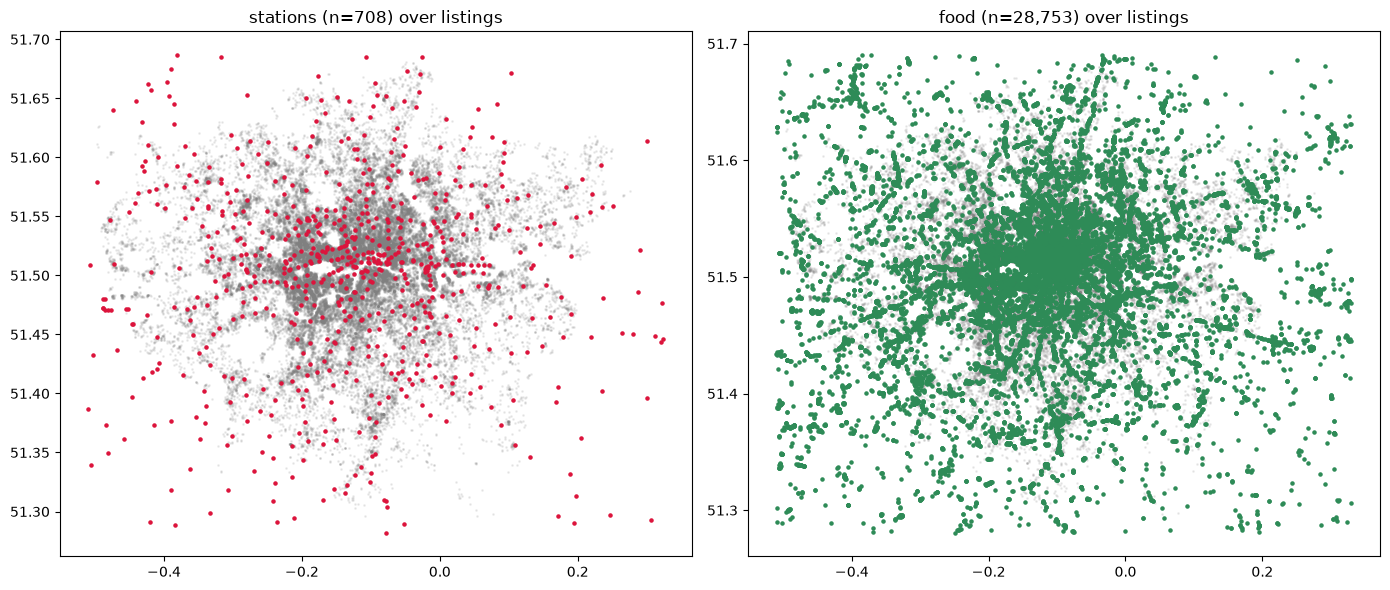

In [4]:
# Eyeball check before trusting any of it: stations should trace the rail network,
# food venues should crowd the centre. If they didn't, the query is wrong.
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for a, key, colour in zip(ax, ["stations", "food"], ["crimson", "seagreen"]):
    a.scatter(df["longitude"], df["latitude"], s=1, alpha=0.12, color="grey")  # listings, faint
    pts = pois[key].to_crs(4326).representative_point()
    a.scatter(pts.x, pts.y, s=5, color=colour)
    a.set_title(f"{key} (n={len(pois[key]):,}) over listings")
plt.tight_layout()

**What we see:** the station dots draw out the familiar rail spider-web; food
venues pile up in the West End and the City and thin toward the edges. Both match
reality, so the map data is sound and we can build features from it.

## 2. Build the features and look at them

In [5]:
# add_location_features() does the projection-and-measure dance for every listing:
# project listings and POIs to metres, then for each listing find the nearest POI
# and count POIs within a radius. It uses a KD-tree - a data structure that splits
# the plane recursively so "find the closest point" costs about log(N) checks
# instead of comparing against all ~30,000 POIs. 60k listings run in ~1 second.
df = add_location_features(df, pois)
df[LOCATION_FEATURES].describe(percentiles=[0.1, 0.5, 0.9]).round(0)

,dist_station_m,stations_within_1km,dist_restaurant_m,food_within_500m,dist_park_m,dist_center_m
count,59450.0,59450.0,59450.0,59450.0,59450.0,59450.0
mean,493.0,4.0,146.0,72.0,192.0,7784.0
std,372.0,3.0,144.0,117.0,154.0,5099.0
min,2.0,0.0,0.0,0.0,0.0,11.0
10%,150.0,1.0,20.0,3.0,46.0,2429.0
50%,407.0,3.0,101.0,37.0,152.0,6368.0
90%,936.0,9.0,336.0,155.0,393.0,15291.0
max,7380.0,17.0,1579.0,921.0,2352.0,28856.0


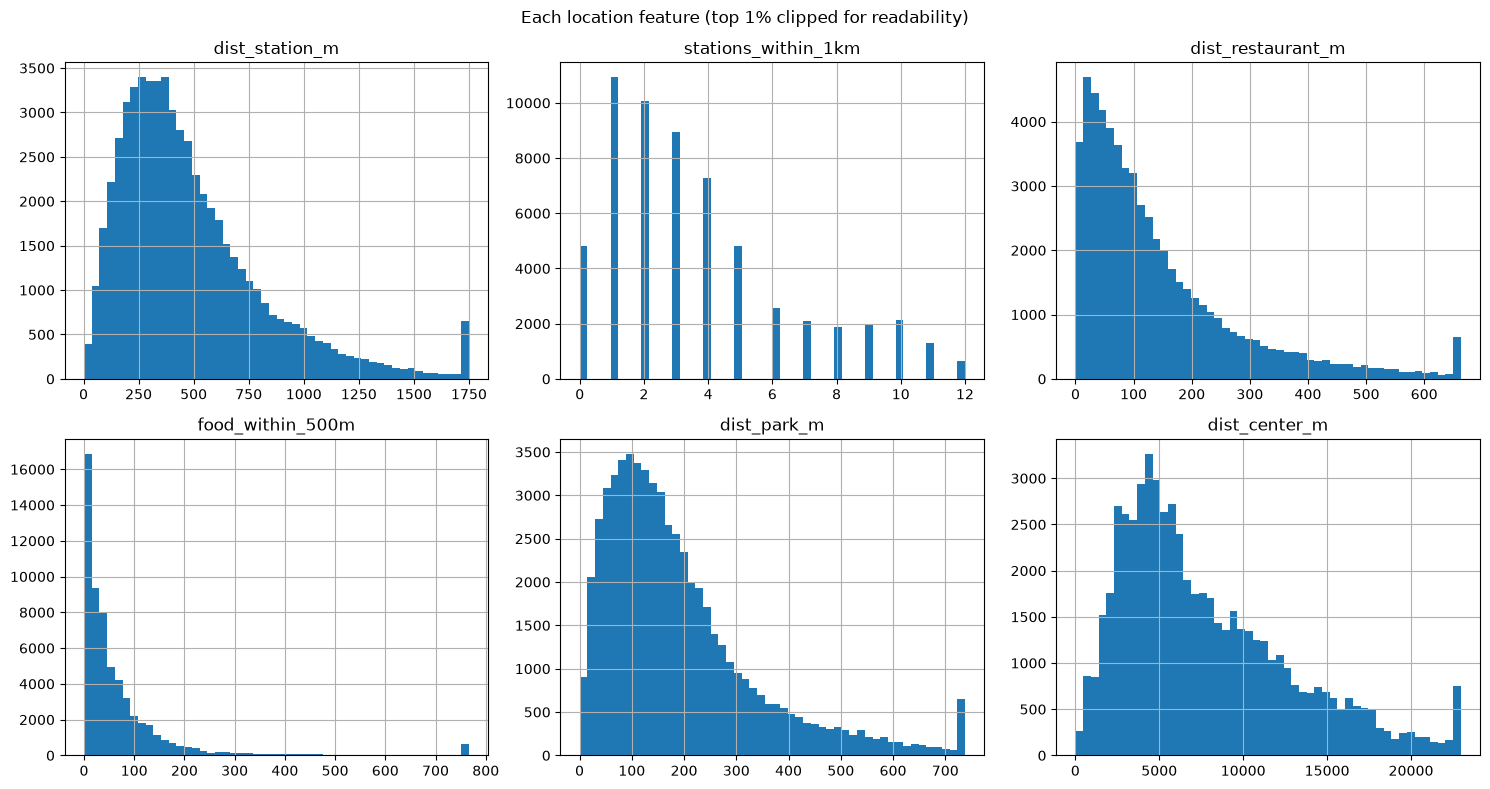

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), LOCATION_FEATURES):
    df[col].clip(upper=df[col].quantile(0.99)).hist(bins=50, ax=ax)  # clip top 1% for readability
    ax.set_title(col)
fig.suptitle("Each location feature (top 1% clipped for readability)")
plt.tight_layout()

**What we see:** half the listings are within ~400 m of a station (a 5-minute
walk) and within ~100 m of somewhere to eat - central London is dense.
`dist_park_m` is small nearly everywhere. `dist_center_m` runs from a few hundred
metres to ~29 km, spreading listings nicely along the centre→edge axis.

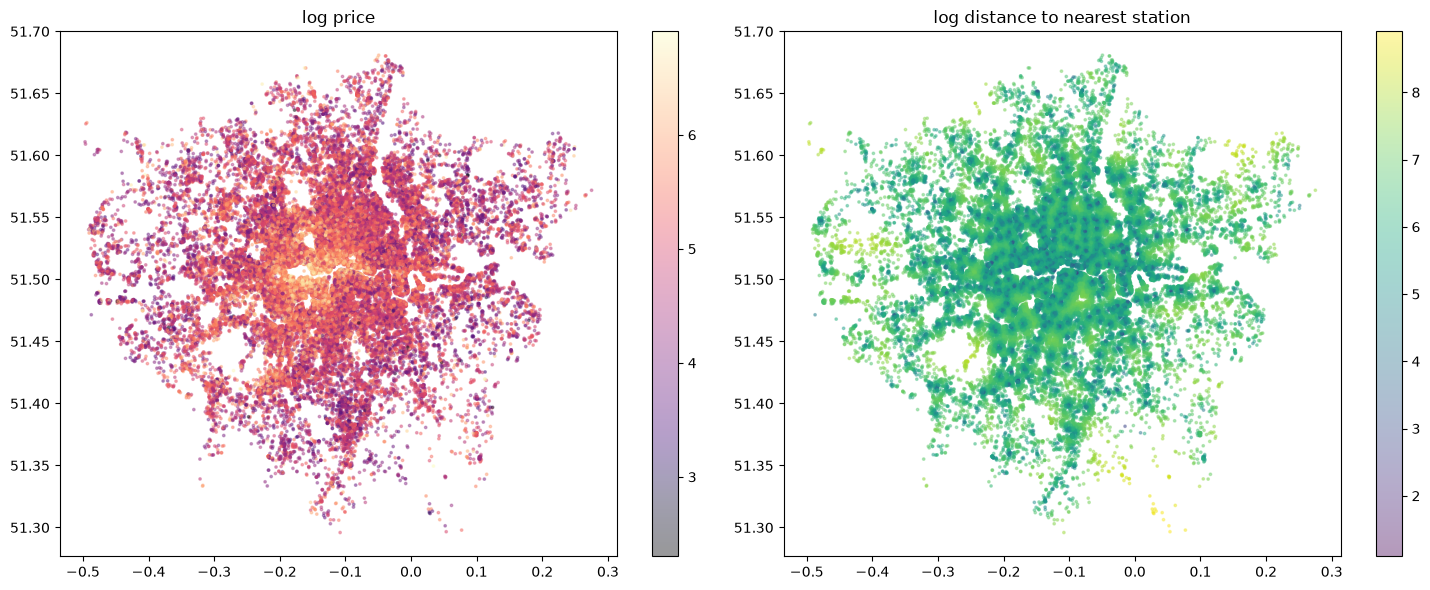

In [7]:
# Do the price gradient and the distance-to-station gradient look like negatives of
# each other? If so, "near a station" and "pricey" go together.
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
s0 = ax[0].scatter(df["longitude"], df["latitude"], c=df["log_price"], s=3, alpha=0.4, cmap="magma")
ax[0].set_title("log price")
fig.colorbar(s0, ax=ax[0])
s1 = ax[1].scatter(
    df["longitude"],
    df["latitude"],
    c=np.log1p(df["dist_station_m"]),
    s=3,
    alpha=0.4,
    cmap="viridis",
)
ax[1].set_title("log distance to nearest station")
fig.colorbar(s1, ax=ax[1])
plt.tight_layout()

### How to read the correlation table below

**Correlation** is a single number from -1 to +1 for the *straight-line* strength
of a relationship. We *expect*:
- **negative** on the distance features - further from a station / the centre →
  cheaper,
- **positive** on the counts - more stuff nearby → dearer.

A backwards sign would mean a broken feature. It only sees straight-line links (the
model handles curves later), so this is a **correctness check**, not the verdict.

In [8]:
df[LOCATION_FEATURES + ["log_price"]].corr(numeric_only=True)["log_price"].drop(
    "log_price"
).sort_values().to_frame("corr with log_price").round(3)

,corr with log_price
dist_center_m,-0.366
dist_restaurant_m,-0.246
dist_station_m,-0.208
dist_park_m,-0.182
food_within_500m,0.271
stations_within_1km,0.312


**What we see:** every sign is what we'd hope - the distance features negative,
the counts positive. Distance-to-centre is the strongest single location signal.

> ### Deeper: why none of these are large, and why that's fine
>
> Every `|correlation|` here is under 0.4. Two reasons, both expected:
> 1. **Price is multi-causal** - size, type, host and more also move it; no single
>    location number can carry much alone.
> 2. **These features overlap with each other.** Near the centre ⇒ usually near a
>    station ⇒ usually near food. When predictors share information (*collinearity*),
>    their individual effects don't simply add up.
>
> So the next section measures their **combined** contribution with a proper
> experiment, rather than trusting the individual numbers.
>
> ISLR §3.3.3 on collinearity.

## 3. The experiment: does location *beyond the borough* actually help?

This is an **ablation** - take a working setup, add one ingredient, measure the
difference, change nothing else.

- **Same model** both times: a **gradient-boosted tree**. *Plain version:* it
  builds hundreds of tiny decision trees one after another; each new tree is
  trained to fix the leftover mistakes of all the trees so far, and the prediction
  is the running total.
- **Same 5-fold cross-validation** both times. *Cross-validation:* split the rows
  into 5 parts; train on 4, score on the held-out 1; rotate through all 5; average.
  It estimates performance on unseen listings.
- **Only the feature list changes:**
  - *baseline*: borough + room type + size (`accommodates`, `bedrooms`, `bathrooms`)
  - *+ location*: the same, plus the six OpenStreetMap features.

If the six features earn their place, error falls and R² rises.

> ### Deeper: the ML ideas in the next cell
>
> - **One-hot encoding.** The model needs numbers, but `neighbourhood_cleansed` is
>   text. One-hot encoding swaps one text column for one 0/1 column per category
>   ("in Camden? 0/1", "in Hackney? 0/1", ...). 33 boroughs → 33 columns.
>   `sparse_output=False` returns a plain dense array (the tree model refuses a
>   sparse one - I hit that error the first time).
> - **`cross_val_predict`** gives an out-of-fold prediction for every row: each row
>   predicted by a model that was trained on the *other* four folds.
>
> Gradient boosting: Friedman (2001), and the StatQuest "Gradient Boost" series.
> Cross-validation: ISLR Ch. 5. One-hot / dummy variables: ISLR §3.3.1.

> **Thought process.** I could have stopped at the correlation table and claimed
> the features work. But those six features overlap heavily (near the centre
> usually means near a station, near food, and so on), so their individual
> correlations do not add up to their real contribution. The only honest way to
> measure that is to add them to a model and re-check under the same CV.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

model = df.dropna(subset=["accommodates", "bedrooms", "bathrooms"]).copy()
y = model["log_price"].to_numpy()
cat = ["neighbourhood_cleansed", "room_type"]
size = ["accommodates", "bedrooms", "bathrooms"]


def cv_scores(feature_cols):
    prep = ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)],
        remainder="passthrough",
    )
    pipe = Pipeline([("prep", prep), ("gbr", HistGradientBoostingRegressor(random_state=0))])
    folds = KFold(n_splits=5, shuffle=True, random_state=0)
    pred_log = cross_val_predict(pipe, model[feature_cols], y, cv=folds)
    return {
        "R2 (log)": r2_score(y, pred_log),
        "MAE (log)": mean_absolute_error(y, pred_log),
        "MAE (GBP)": mean_absolute_error(np.exp(y), np.exp(pred_log)),  # exp() -> back to £
    }


pd.DataFrame(
    {
        "baseline: borough + room + size": cv_scores(cat + size),
        "+ location features": cv_scores(cat + size + LOCATION_FEATURES),
    }
).T.round(3)

,R2 (log),MAE (log),MAE (GBP)
baseline: borough + room + size,0.616,0.312,77.741
+ location features,0.653,0.292,72.299


### Results

| Model | R² (log) | MAE (£/night) |
|---|---|---|
| baseline: borough + room type + size | 0.616 | 77.7 |
| **+ 6 location features** | **0.653** | **72.3** |

**Plain reading.** Adding "how far to the Tube / a park / the buzz / the centre"
cut the typical miss by about **£5.40 a night (≈7% smaller)** and lifted R² from
0.62 to 0.65. Modest, but consistent, and it matches the correlation signs.
**Decision: keep all six features** - cheap to compute, easy to explain, fully
reproducible (the OSM extracts are committed to the repo).

> ### Deeper: why the gain is "only" a few pounds, and is that good?
>
> The borough dummy already absorbs most of the *coarse* geography. The six
> features add the **within-borough** signal - a genuinely smaller slice of the
> pie. A £5/night structural improvement *on top of a strong baseline*, from six
> columns that cost nothing, is a solid result. Notebook 03 uses SHAP to show *how*
> the model spends them on individual listings.
>
> **What I'd try next:** distance to a park's *boundary*, not its centre (a listing
> next to a huge park currently looks "far" from it); and distances to several
> centres (City, West End, Canary Wharf) instead of just Charing Cross.

## Honest limitations

- **Parks are measured to their centre, not their nearest edge.** Fixable by
  measuring to the park polygon; noted for a v2.
- **`dist_center_m` is one point.** London has several centres; a single distance
  flattens that.
- **OpenStreetMap is crowd-sourced.** Coverage is excellent centrally, thinner at
  the edges, so outer-borough counts may be slight undercounts.
- **Spatial autocorrelation.** Two listings on the same street are near-duplicates.
  A *random* CV split can put one in training and its twin in test, flattering the
  score. Notebook 03 switches to holding out whole geographic blocks.
  > Roberts et al. (2017), *Ecography* - the standard reference for blocking CV
  > folds under spatial autocorrelation.

### Week-2 exit checklist
- [x] Location features built and cached (`data/external/osm_*.gpkg`, committed)
- [x] Every correlation sign matches intuition (distances -, counts +)
- [x] Ablation run: borough+size vs +location, same model, same folds
- [x] Decision recorded (keep all six)
- [x] Limitations written down